In [1]:
import geopandas as gpd
import pandas as pd
from blocksnet.config import log_config

log_config.set_logger_level('WARNING')

# Оценка стоимости земли проекта

In [2]:
scenario_blocks = pd.read_pickle('../data/scenario_blocks.pickle')
scenario_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180
1,"POLYGON ((388558.037 6645102.374, 388511.373 6...",0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081
2,"POLYGON ((387957.434 6643444.937, 388007.492 6...",0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381
3,"POLYGON ((388007.492 6643608.409, 387957.434 6...",0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862
4,"POLYGON ((388001.306 6643195.969, 388000.75 66...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN


In [3]:
blocks = pd.read_pickle('../data/prepared_blocks.pickle')
blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_scn,geometry,id
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.339339,...,202399.732193,0.062008,0.030931,0.000000,2.004749,low-rise non-residential,83.073985,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.803825,...,201529.493481,0.202340,0.090031,0.000000,2.247463,low-rise non-residential,82.652504,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.639457,...,164663.859830,0.151737,0.091165,0.000000,1.664418,low-rise non-residential,109.288479,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.050757,...,161571.832511,0.449142,0.139053,0.404539,3.230005,low-rise model,112.015000,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316008,...,16.489152,0.079224,0.019165,0.000000,4.133894,mid-rise non-residential,82.790797,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4


In [4]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('../data/catboost_model.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=blocks,
)
blocks_pred = estimator.predict()



In [6]:
blocks_pred.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,gsi,mxi,l,morphotype,area_accessibility,is_scn,geometry,id,y_log_pred,price_pred
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.339339,...,0.030931,0.000000,2.004749,low-rise non-residential,83.073985,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0,19.562409,3.132176e+08
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.803825,...,0.090031,0.000000,2.247463,low-rise non-residential,82.652504,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1,19.670017,3.488025e+08
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.639457,...,0.091165,0.000000,1.664418,low-rise non-residential,109.288479,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2,19.223868,2.232646e+08
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.050757,...,0.139053,0.404539,3.230005,low-rise model,112.015000,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3,20.394163,7.195687e+08
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316008,...,0.019165,0.000000,4.133894,mid-rise non-residential,82.790797,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4,10.954897,5.723364e+04


# Визуализация стоимости земли

Суммарная стоимость:
 • Сценические кварталы: 10 154 928 952 ₽
 • Контекст: 203 555 813 231 ₽
 • Все кварталы: 213 710 742 182 ₽


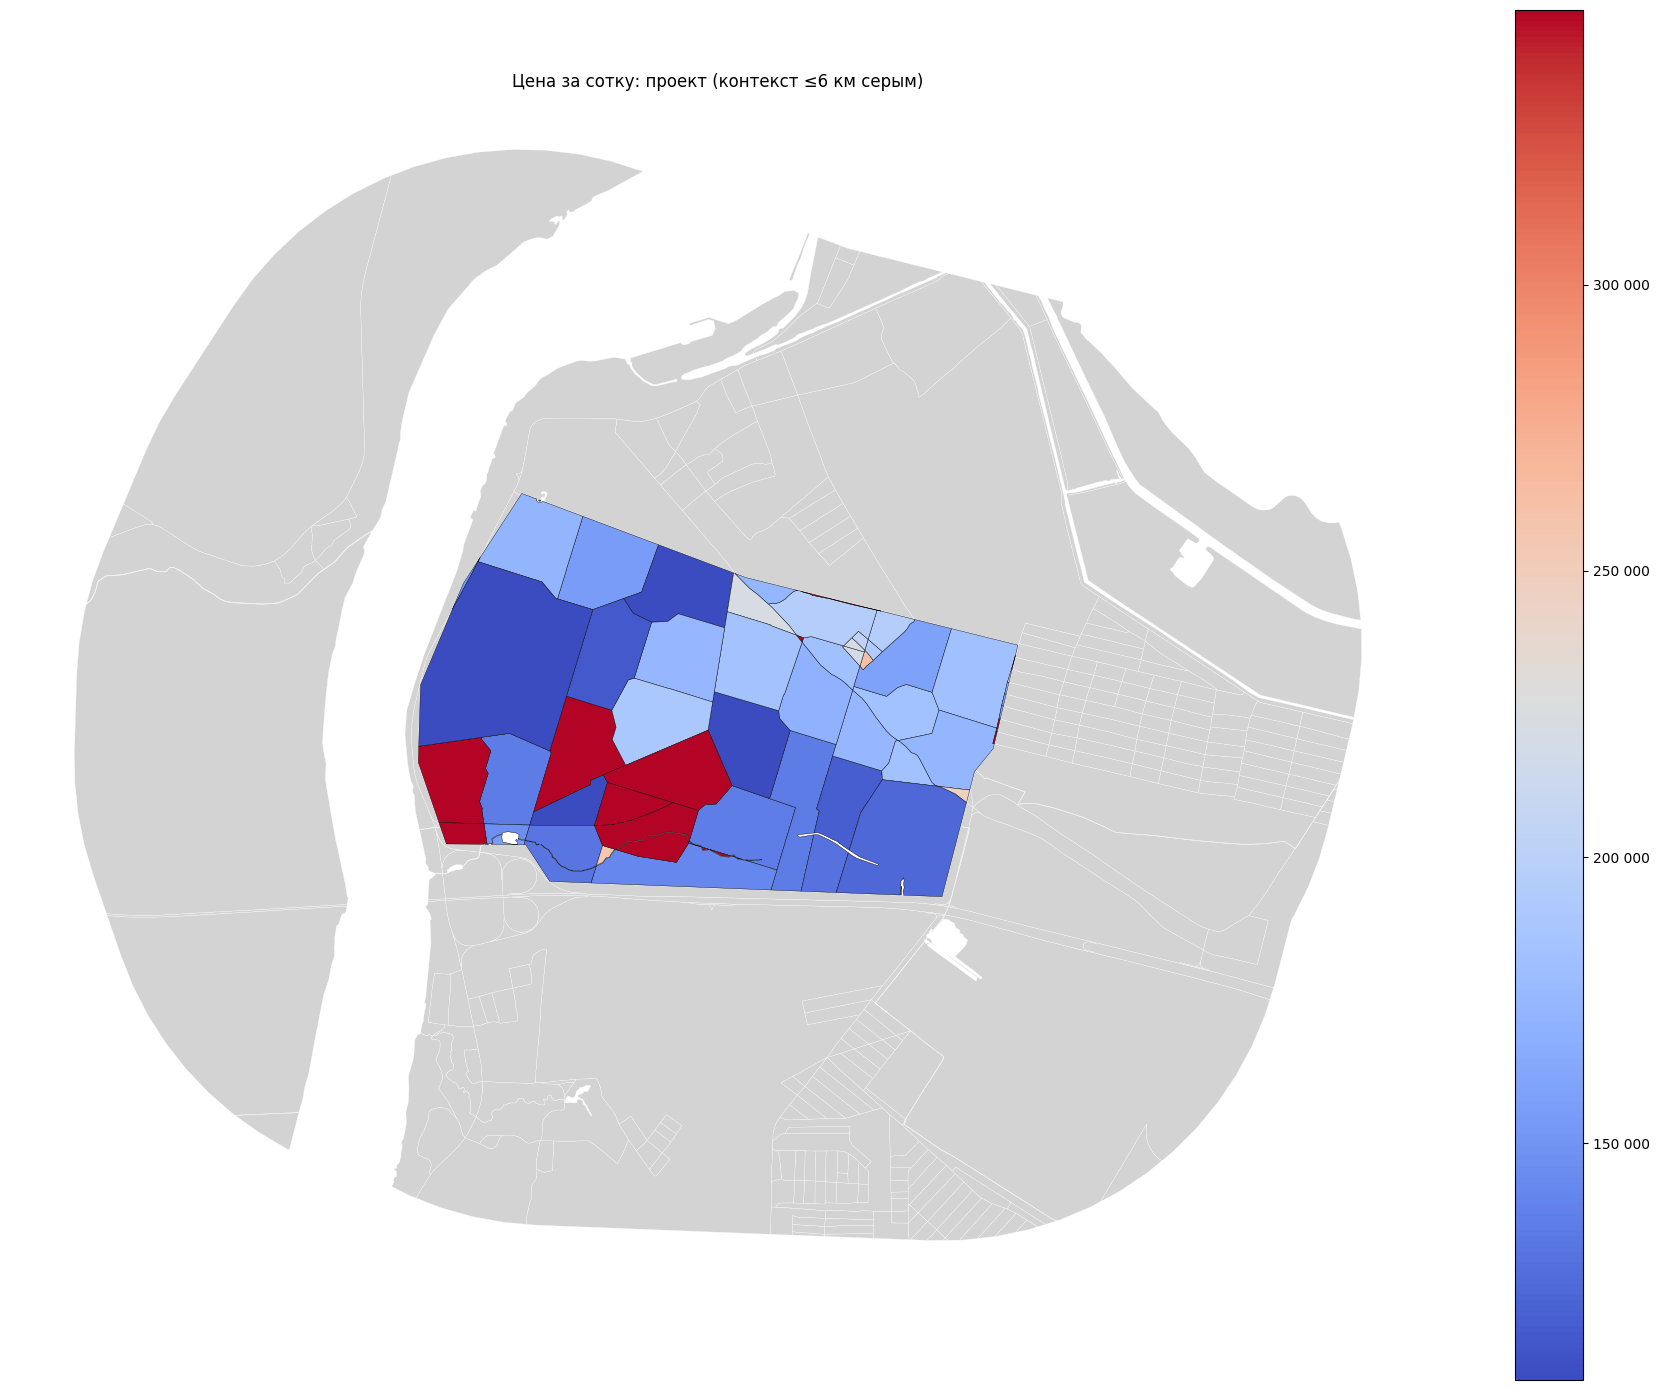

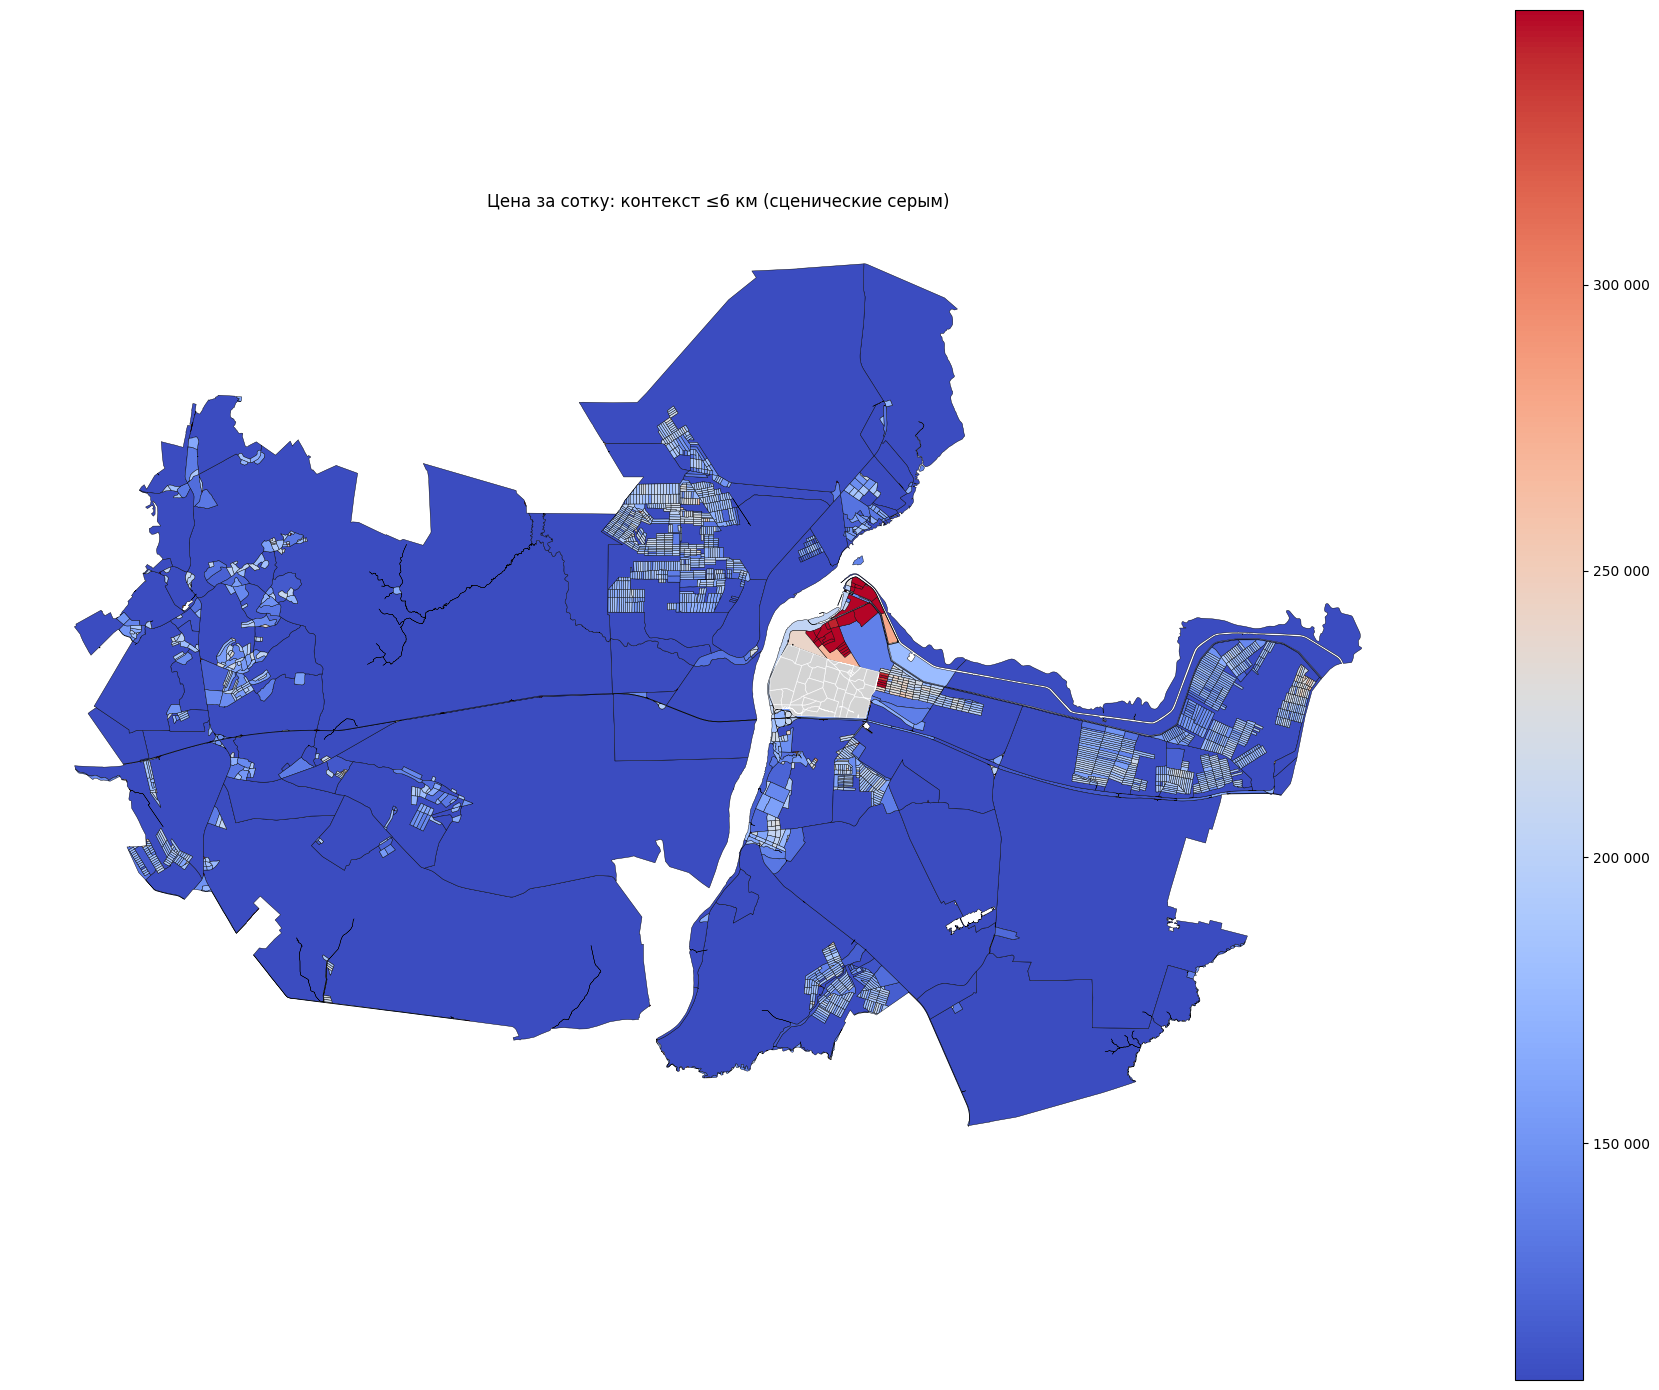

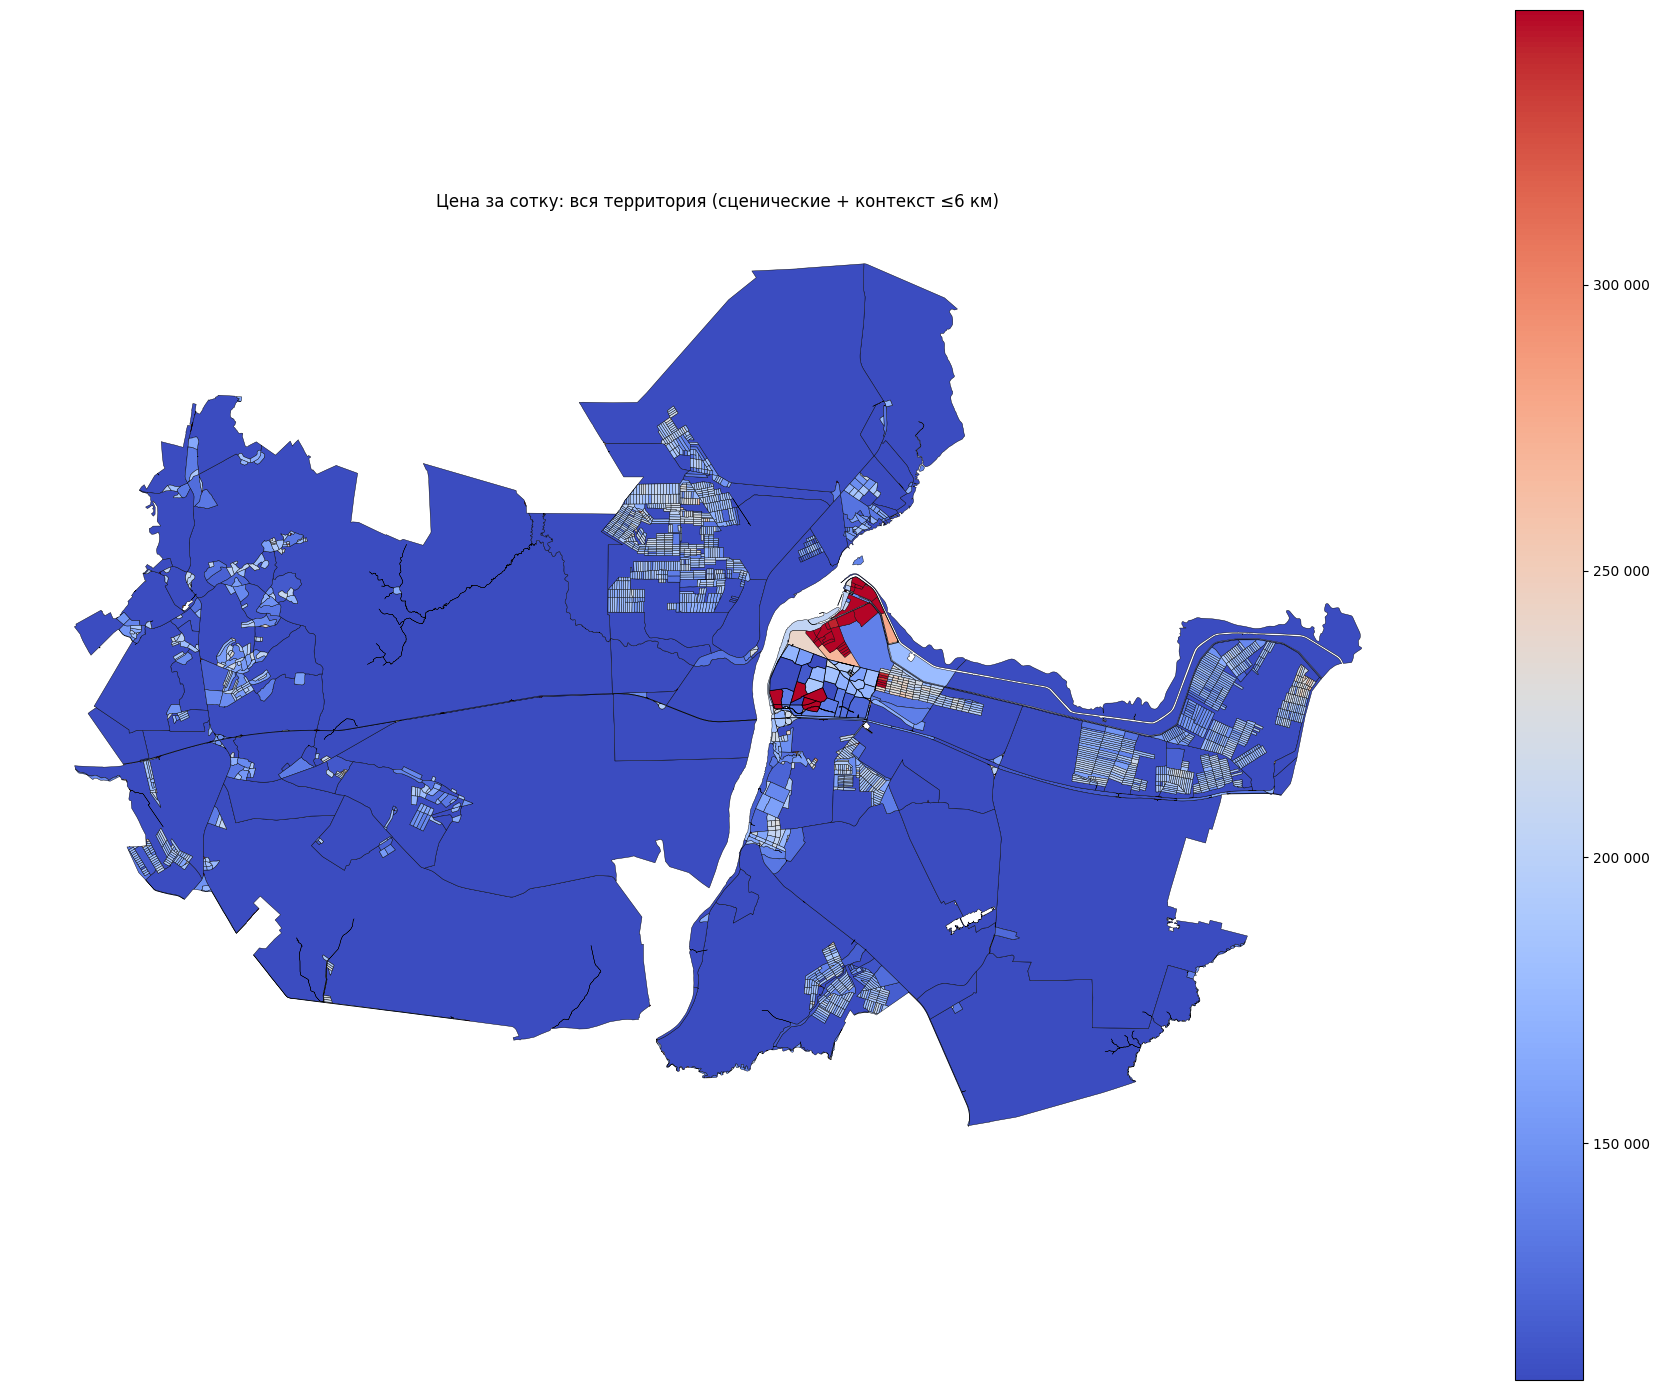

In [7]:
from urbanomy.methods.land_value_modeling import plot_land_price_maps

visualization_output = plot_land_price_maps(
    blocks_pred=blocks_pred,
    scenario_blocks=scenario_blocks,
    buffer_radius_m=2000,
)



In [8]:
blocks_pred.to_pickle('../data/blocks_with_price.pickle')

# Сценарное изменение ТЭП участков

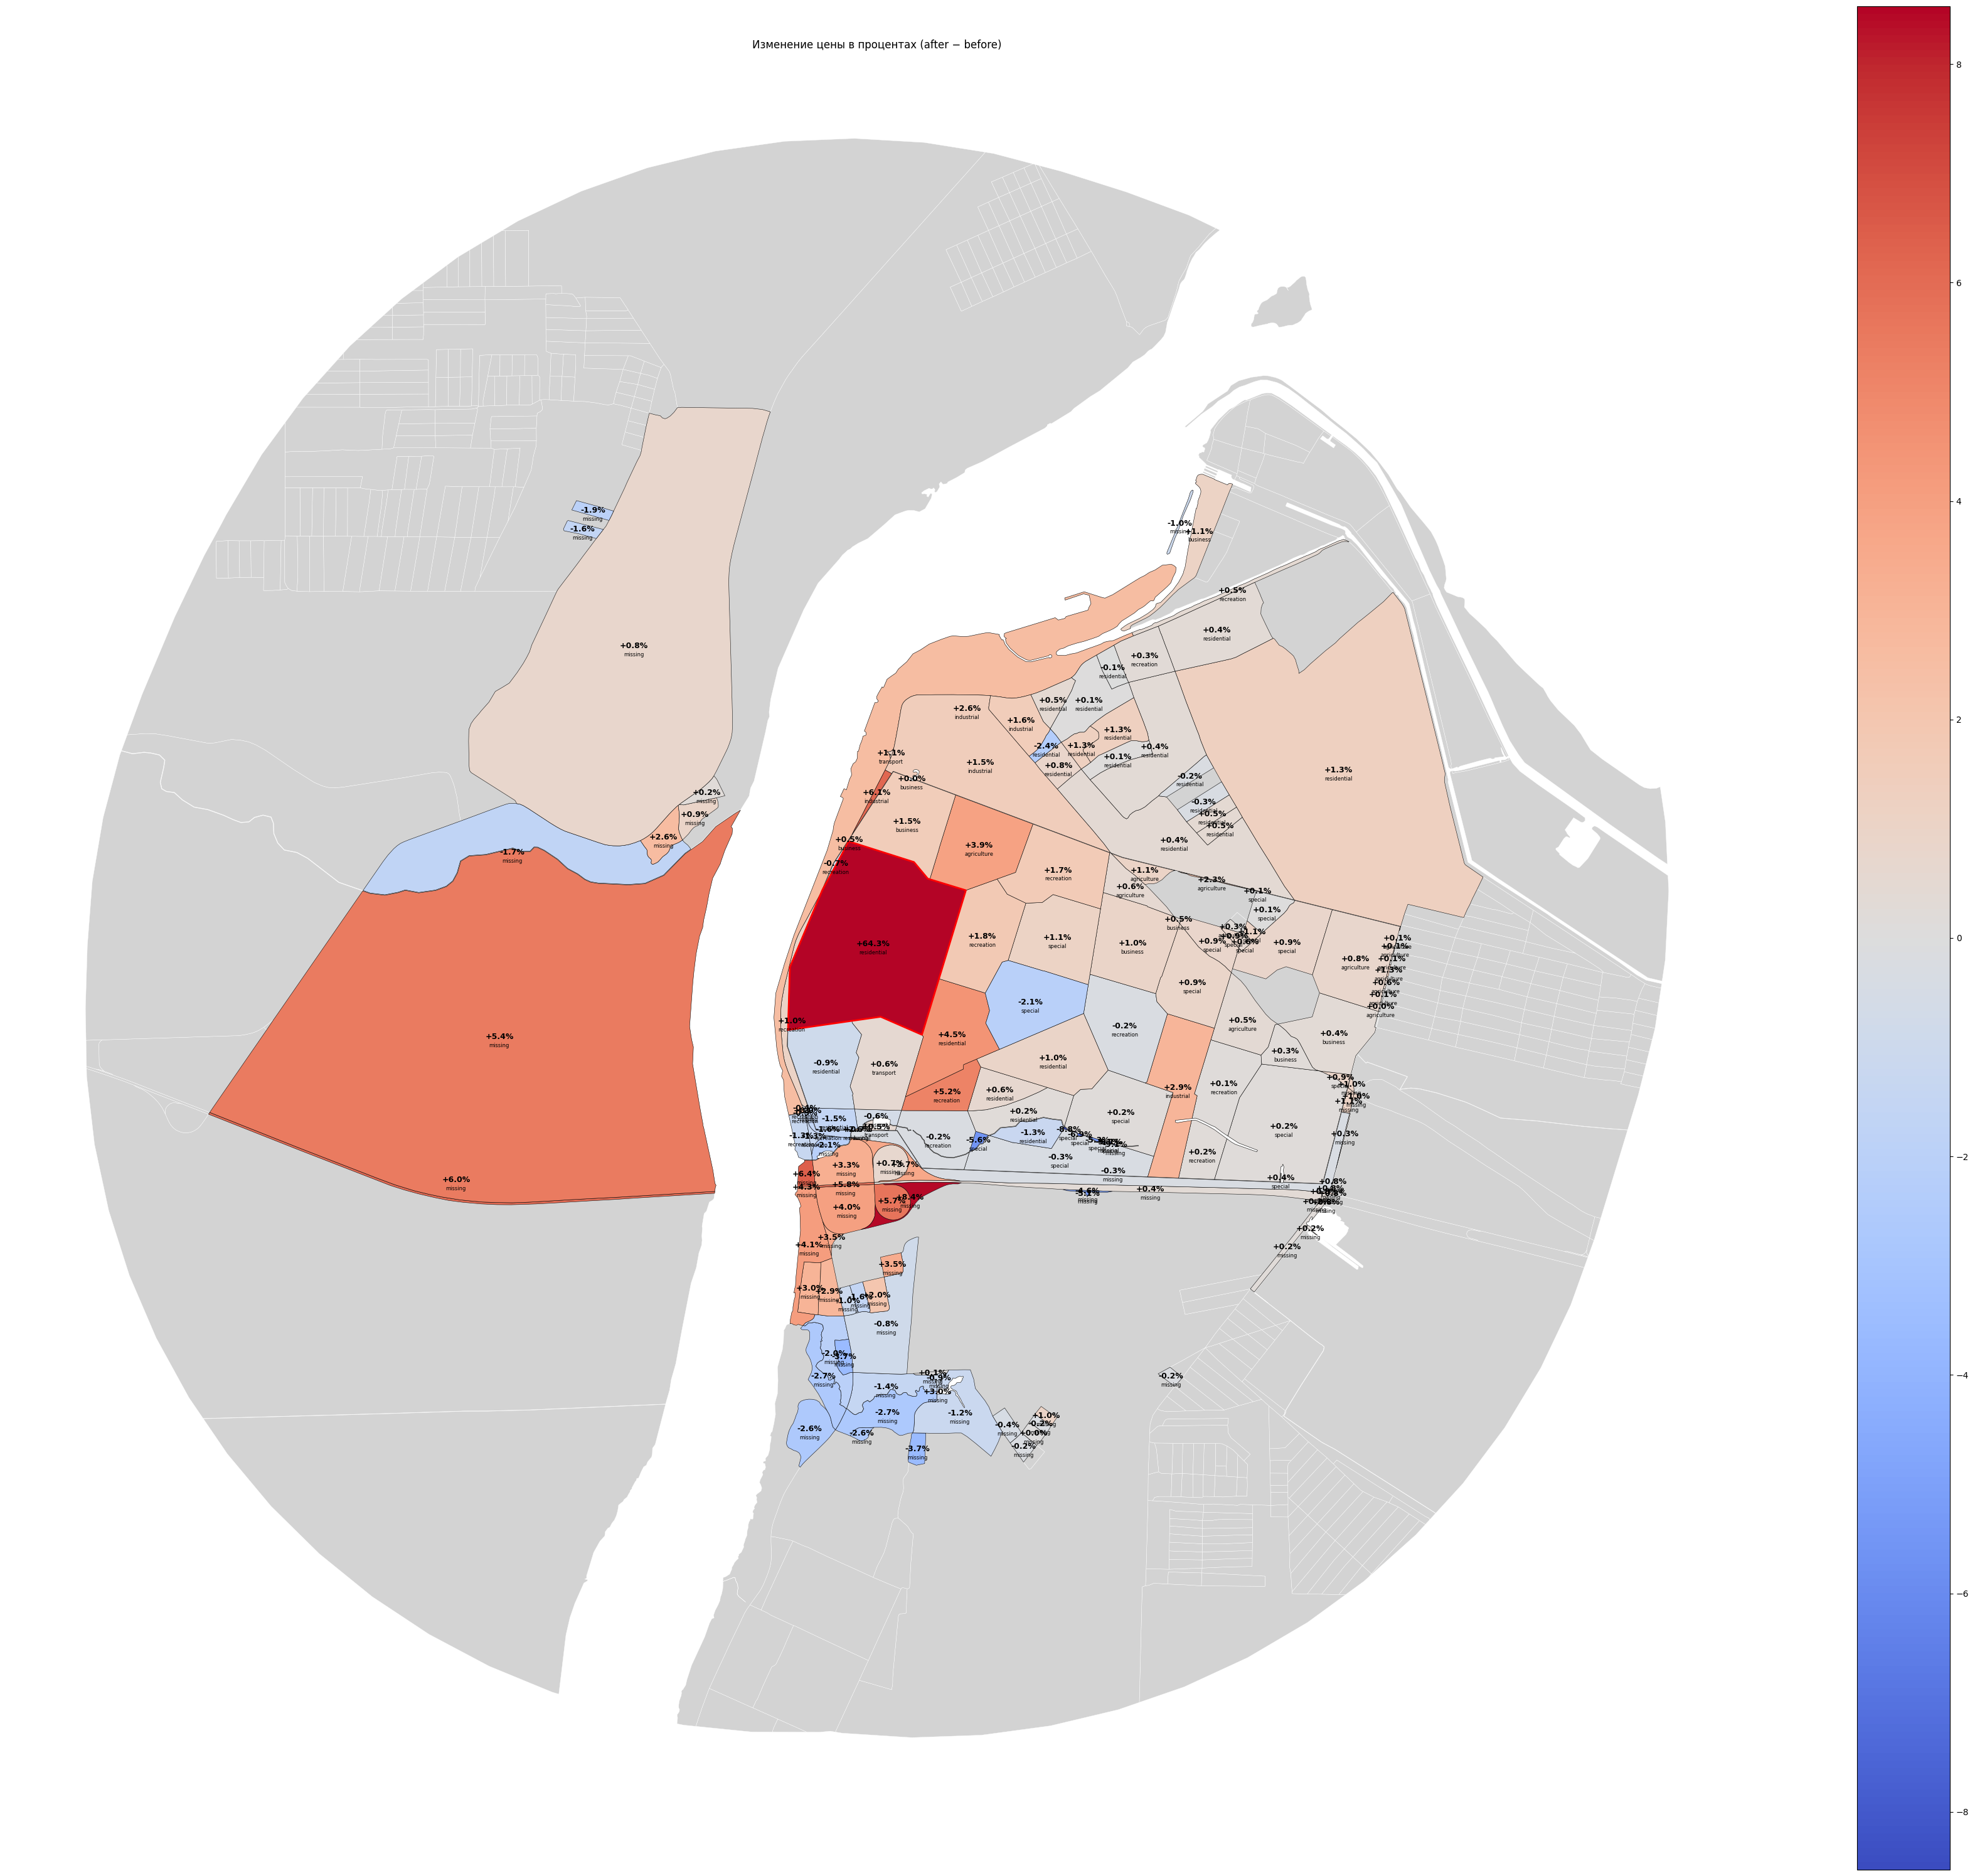


Статистика по кварталам в пределах буфера (|Δ₽| > 1e-09):
index | до (₽) → после (₽) | Δ₽ | Δ%
377 | 122 570 ₽ → 123 580 ₽ | +1 010 ₽ | +0.8%
387 | 120 031 ₽ → 121 020 ₽ | +989 ₽ | +0.8%
388 | 3 055 917 ₽ → 3 081 090 ₽ | +25 174 ₽ | +0.8%
1421 | 119 116 ₽ → 120 097 ₽ | +981 ₽ | +0.8%
1450 | 130 985 ₽ → 132 064 ₽ | +1 079 ₽ | +0.8%
1568 | 17 586 905 ₽ → 17 765 313 ₽ | +178 407 ₽ | +1.0%
1525 | 32 792 234 ₽ → 32 860 467 ₽ | +68 233 ₽ | +0.2%
1559 | 16 582 383 ₽ → 16 553 301 ₽ | -29 082 ₽ | -0.2%
614 | 2 189 411 ₽ → 2 076 699 ₽ | -112 712 ₽ | -5.1%
326 | 105 057 034 ₽ → 105 470 562 ₽ | +413 528 ₽ | +0.4%
378 | 6 469 336 ₽ → 6 173 165 ₽ | -296 171 ₽ | -4.6%
12 | 256 437 442 ₽ → 255 625 627 ₽ | -811 815 ₽ | -0.3%
325 | 247 279 997 ₽ → 246 489 863 ₽ | -790 134 ₽ | -0.3%
48 | 68 836 ₽ → 62 563 ₽ | -6 273 ₽ | -9.1%
49 | 70 824 ₽ → 64 370 ₽ | -6 454 ₽ | -9.1%
1451 | 6 806 346 ₽ → 6 824 016 ₽ | +17 670 ₽ | +0.3%
617 | 15 140 115 ₽ → 15 305 658 ₽ | +165 543 ₽ | +1.1%
2552 | 4 127 159 ₽ → 4 168 8

In [9]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks
changes = {
    'land_use': 'LandUse.RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168
}
target_idx = 62

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
)

